# Biomedical Data Design · SegRap2023 figures

Each numbered cell below is self-contained: run **cell 1 (setup)** once per Colab session, then run any figure cell on its own.
Figures are saved to `Biomedical Data Design/outputs/` in Drive so they persist after the runtime shuts down.

## 1 · Setup: mount Drive, install libraries, define paths

In [ ]:
# 1 · SETUP — run once per session
from google.colab import drive
drive.mount('/content/drive')

!pip install -q nibabel

import os
from pathlib import Path

ROOT = Path('/content/drive/MyDrive/Biomedical Data Design')
DATA = ROOT / 'SegRap2023_Training_Set_120cases'
OUT  = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)

cases = sorted(p.name for p in DATA.glob('segrap_*'))
print(f'{len(cases)} cases found, e.g. {cases[:3]}')
print('example case contents:', len(list((DATA / cases[0]).glob('*.nii.gz'))), 'files')
print('outputs go to', OUT)

Mounted at /content/drive
120 cases found, e.g. ['segrap_0000', 'segrap_0001', 'segrap_0002']
example case contents: 49 files
outputs go to /content/drive/MyDrive/Biomedical Data Design/outputs


In [ ]:
# For those who have the folder as a shortcut as opposed to owning

from google.colab import drive
drive.mount('/content/drive')

!pip install -q nibabel

from pathlib import Path

ROOT = Path('/content/drive/MyDrive/Biomedical Data Design')
DATA = ROOT / 'SegRap2023_Training_Set_120cases'
OUT = ROOT / 'outputs'

# Create outputs folder if it does not already exist
OUT.mkdir(parents=True, exist_ok=True)

# Check that the dataset shortcut/path is accessible
if not DATA.exists():
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA}\n\n"
        "Make sure the shared folder has been added as a shortcut to My Drive "
        "and that ROOT matches the shortcut location."
    )

cases = sorted(p.name for p in DATA.glob('segrap_*'))

print(f'{len(cases)} cases found, e.g. {cases[:3]}')
print('Example case contents:',
      len(list((DATA / cases[0]).glob('*.nii.gz'))),
      'files')
print('Outputs go to:', OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
120 cases found, e.g. ['segrap_0000', 'segrap_0001', 'segrap_0002']
Example case contents: 49 files
Outputs go to: /content/drive/MyDrive/Biomedical Data Design/outputs


## 2 · Look at one mask (three orthogonal slices)

Picks the slice with the most mask voxels along each axis, so small structures still show up. Change `CASE` and `ORGAN` freely.

segrap_0106/Brain: shape (1024, 1024, 122), spacing 0.493×0.493×3.0 mm, volume 1396.5 cm³


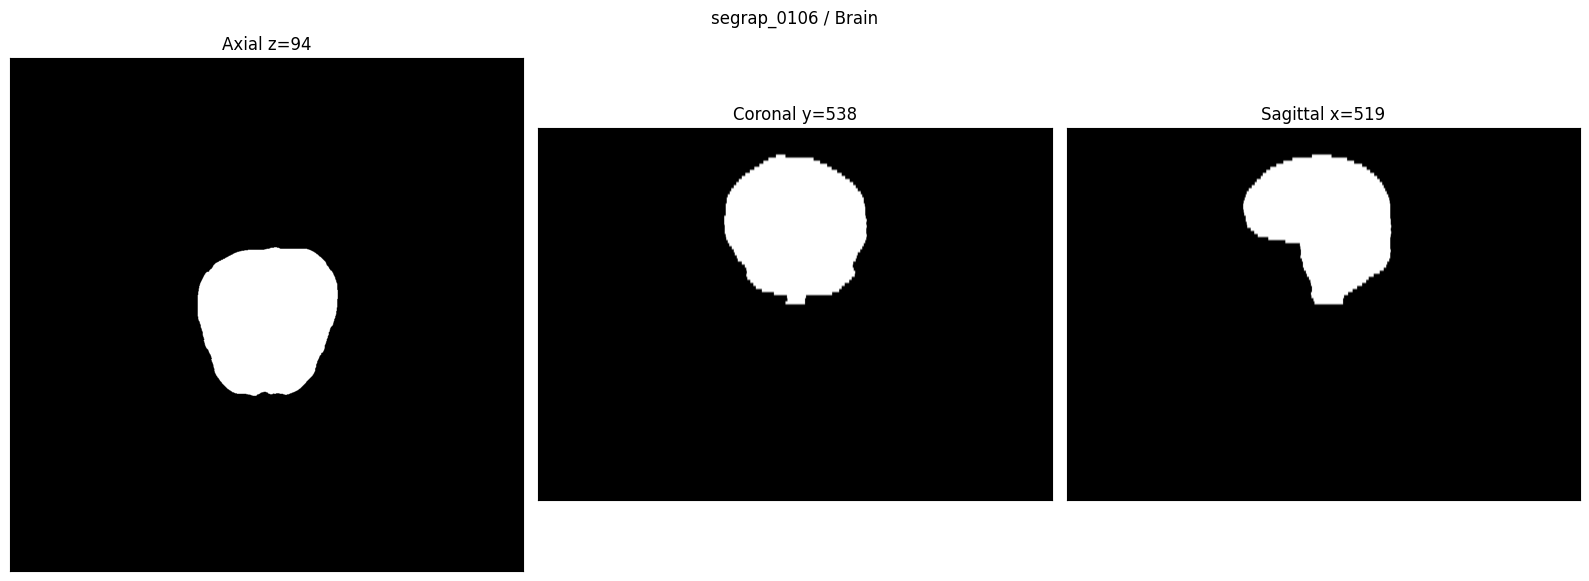

In [ ]:
# 2 · ONE MASK, THREE VIEWS
import numpy as np, nibabel as nib, matplotlib.pyplot as plt

CASE, ORGAN = 'segrap_0106', 'Brain'

img = nib.load(DATA / CASE / f'{ORGAN}.nii.gz')
data = np.asarray(img.dataobj) > 0            # masks may be 0/1 or 0/255 → treat any >0 as inside
sx, sy, sz = (float(v) for v in img.header.get_zooms()[:3])
n = int(data.sum())
print(f'{CASE}/{ORGAN}: shape {data.shape}, spacing {sx:.3f}×{sy:.3f}×{sz:.1f} mm, volume {n*sx*sy*sz/1000:.1f} cm³')

cz = int(data.sum((0, 1)).argmax()); cy = int(data.sum((0, 2)).argmax()); cx = int(data.sum((1, 2)).argmax())
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
ax[0].imshow(data[:, :, cz].T, cmap='gray', origin='lower', aspect=sy / sx); ax[0].set_title(f'Axial z={cz}')
ax[1].imshow(data[:, cy, :].T, cmap='gray', origin='lower', aspect=sz / sx); ax[1].set_title(f'Coronal y={cy}')
ax[2].imshow(data[cx, :, :].T, cmap='gray', origin='lower', aspect=sz / sy); ax[2].set_title(f'Sagittal x={cx}')
for a in ax: a.set_xticks([]); a.set_yticks([])
fig.suptitle(f'{CASE} / {ORGAN}'); fig.tight_layout()
fig.savefig(OUT / f'mask_{CASE}_{ORGAN}.png', dpi=110); plt.show()

## 3 · Axial CT slices: plain, with organ masks, and the crowded skull base

Produces four PNGs from one case: a bare CT slice, the same slice with several organ masks, a skull-base slice with all structures present, and a zoom on one temporal bone.
Reads all 45 organ masks of the case, so it takes a minute or two on Colab.

neck slice z = 65 | skull-base slice z = 75 with 17 structures


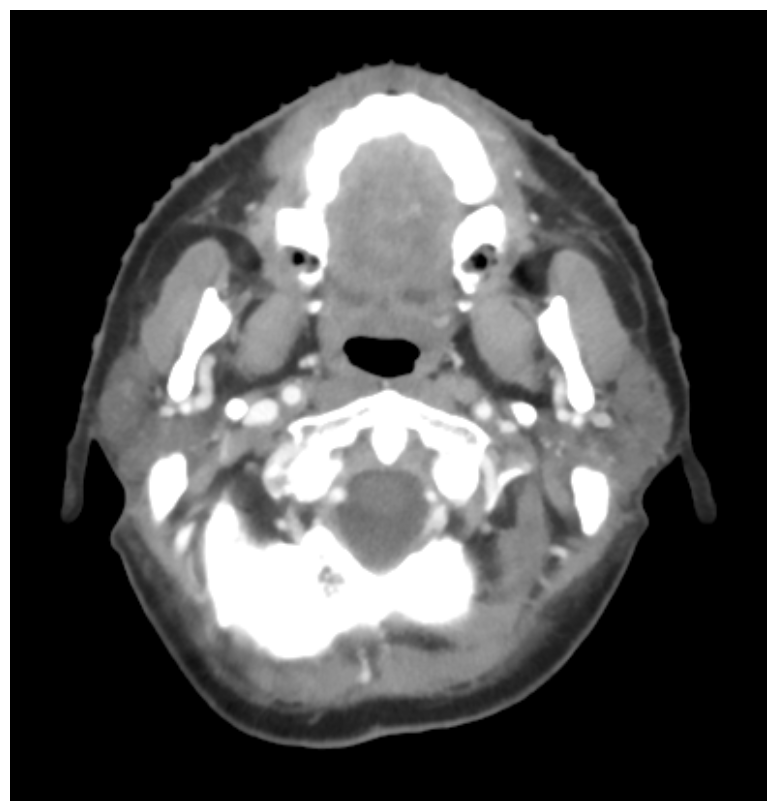

saved /content/drive/MyDrive/Biomedical Data Design/outputs/01_ct_axial_plain.png


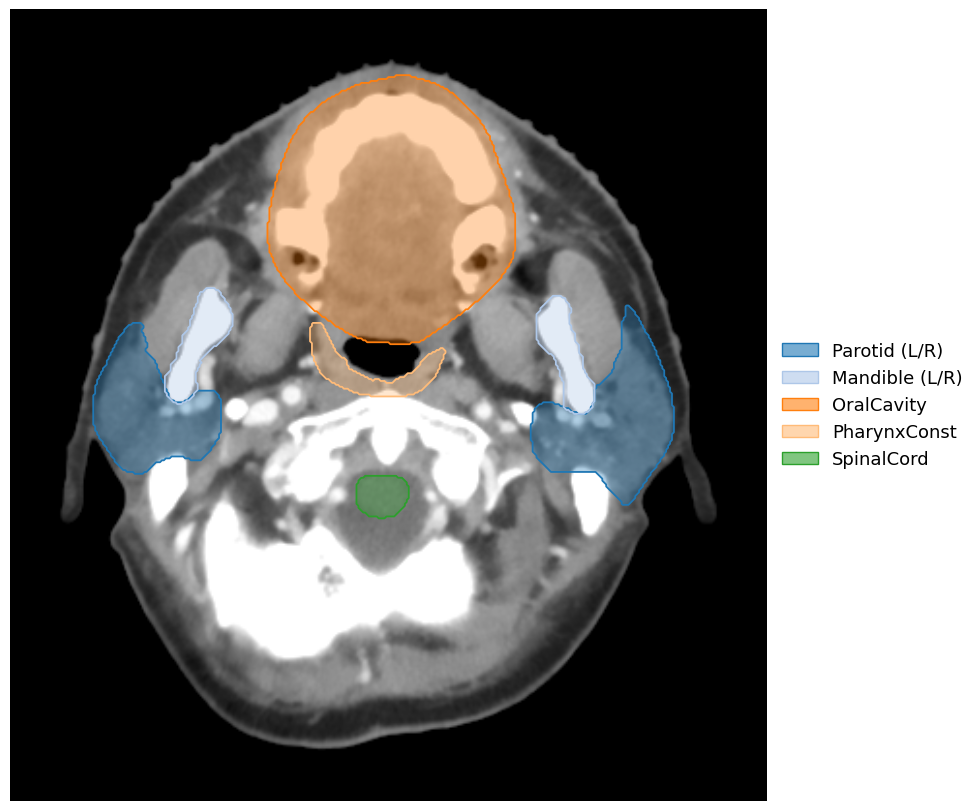

saved /content/drive/MyDrive/Biomedical Data Design/outputs/02_ct_axial_organ_masks.png


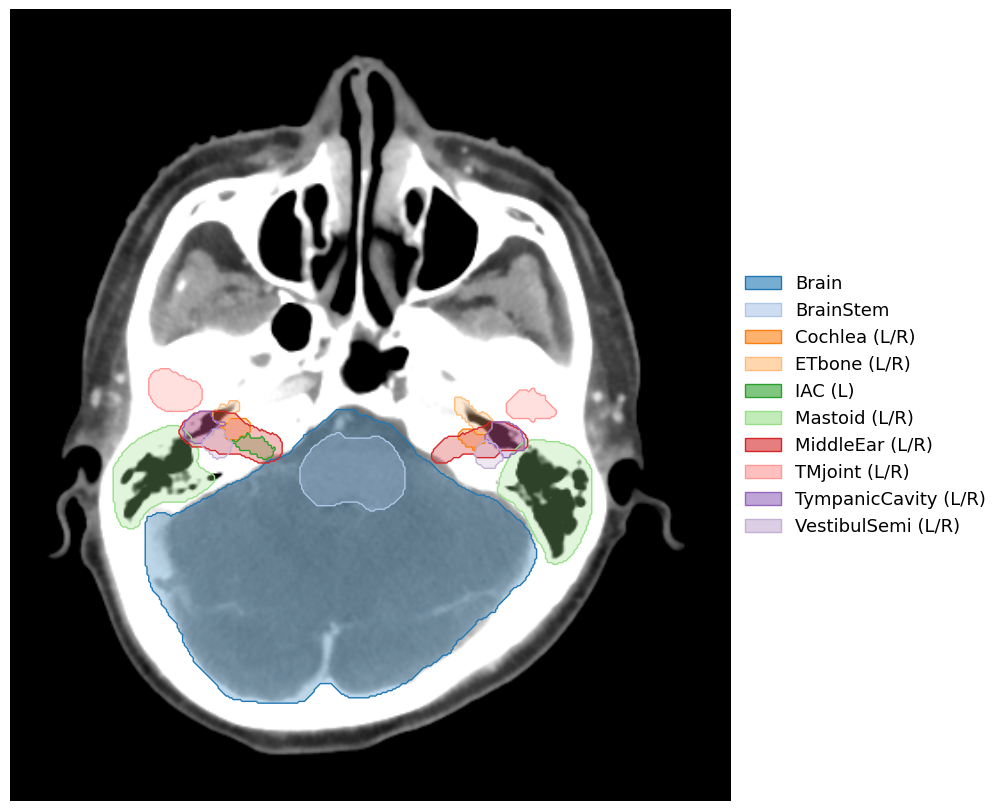

saved /content/drive/MyDrive/Biomedical Data Design/outputs/03_ct_axial_skullbase_complex.png


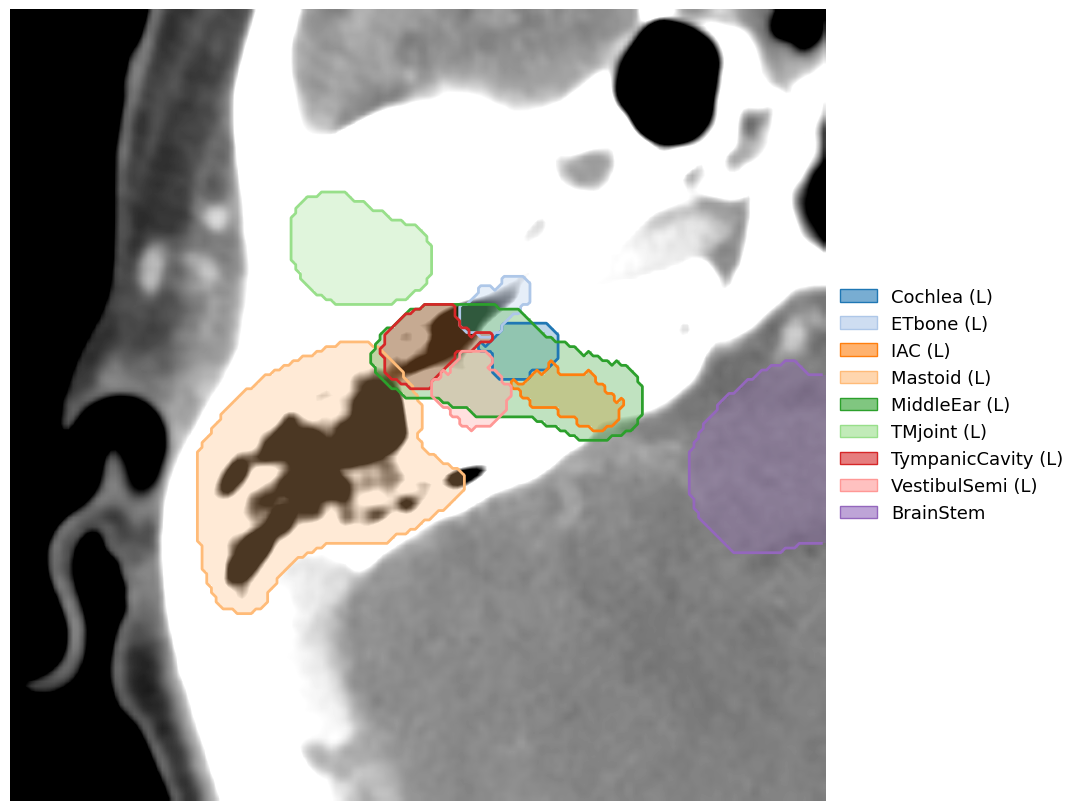

saved /content/drive/MyDrive/Biomedical Data Design/outputs/04_ct_axial_skullbase_zoom.png


In [ ]:
import os, glob, numpy as np, nibabel as nib, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import ndimage

CASE = 'segrap_0106'
case = DATA / CASE
WIN_LO, WIN_HI = -160, 240                      # soft-tissue window W=400 / L=40

def load_canonical(p):                           # reorient to RAS so axial slices show anterior up, patient left on image right
    return nib.as_closest_canonical(nib.load(p))

ct_img = load_canonical(case / 'image_contrast.nii.gz')
ct = np.asarray(ct_img.dataobj).astype(np.float32)
nz = ct.shape[2]

organ_files = sorted(f for f in case.glob('*.nii.gz') if not f.name.startswith('image') and '(' not in f.name)
organs = [f.name[:-7] for f in organ_files]

# pass 1: voxels per slice for each organ (used to choose slice levels)
counts = {}
for f, name in zip(organ_files, organs):
    m = load_canonical(f); assert np.allclose(m.affine, ct_img.affine)
    counts[name] = (np.asarray(m.dataobj) > 0).sum(axis=(0, 1))

def present(z): return [n for n in organs if counts[n][z] > 0 and not n.startswith('GTV')]

need = ['Parotid_L', 'Parotid_R', 'Mandible_L', 'Mandible_R', 'OralCavity', 'PharynxConst', 'SpinalCord']
zA = max([z for z in range(nz) if all(counts[n][z] > 0 for n in need)], key=lambda z: counts['Parotid_L'][z] + counts['Parotid_R'][z])
zB = max(range(nz), key=lambda z: (len(present(z)), counts['Cochlea_L'][z] + counts['Cochlea_R'][z]))
print('neck slice z =', zA, '| skull-base slice z =', zB, 'with', len(present(zB)), 'structures')

# pass 2: read only those two slices of each organ
slices = {zA: {}, zB: {}}
for f, name in zip(organ_files, organs):
    m = load_canonical(f)
    for z in slices:
        if counts[name][z] > 0: slices[z][name] = np.asarray(m.dataobj[:, :, z]) > 0

def head_crop(z, pad=25):                        # largest connected soft-tissue blob = the head, not the table
    lab, n = ndimage.label(ndimage.binary_opening(ct[:, :, z] > -400, iterations=3))
    sizes = ndimage.sum(np.ones_like(lab), lab, range(1, n + 1))
    xs, ys = np.where(lab == np.argmax(sizes) + 1)
    return max(xs.min() - pad, 0), min(xs.max() + pad, ct.shape[0]), max(ys.min() - pad, 0), min(ys.max() + pad, ct.shape[1])

def base(n): return n[:-2] if n.endswith(('_L', '_R')) else n
PALETTE = plt.cm.tab20.colors + plt.cm.tab20b.colors

def render(z, names, fname, crop, fill_alpha=0.35, lw=1.3):
    x0, x1, y0, y1 = crop
    img = ct[x0:x1, y0:y1, z].T
    fig, ax = plt.subplots(figsize=(8 * img.shape[1] / img.shape[0] + (3.2 if names else 0), 8), facecolor='white')
    ax.imshow(img, cmap='gray', vmin=WIN_LO, vmax=WIN_HI, origin='lower', interpolation='bilinear')
    handles, groups = [], []
    for n in names:
        if base(n) not in groups: groups.append(base(n))
    for i, g in enumerate(groups):
        color = PALETTE[i % len(PALETTE)]
        for n in [n for n in names if base(n) == g]:
            mk = slices[z][n][x0:x1, y0:y1].T
            rgba = np.zeros(mk.shape + (4,)); rgba[mk] = (*color, fill_alpha)
            ax.imshow(rgba, origin='lower', interpolation='nearest')
            ax.contour(mk.astype(float), levels=[0.5], colors=[color], linewidths=lw)
        sides = sorted(n[-1] for n in names if base(n) == g and n.endswith(('_L', '_R')))
        handles.append(Patch(facecolor=(*color, 0.6), edgecolor=color, label=g + (f" ({'/'.join(sides)})" if sides else '')))
    ax.set_axis_off(); ax.set_aspect('equal')
    if handles: ax.legend(handles=handles, loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False, fontsize=13, borderaxespad=0)
    fig.tight_layout(pad=0.3); fig.savefig(OUT / fname, dpi=220, facecolor='white', bbox_inches='tight'); plt.show(); print('saved', OUT / fname)

cropA, cropB = head_crop(zA), head_crop(zB)
render(zA, [], '01_ct_axial_plain.png', cropA)
render(zA, [n for n in need if n in slices[zA]], '02_ct_axial_organ_masks.png', cropA)
render(zB, present(zB), '03_ct_axial_skullbase_complex.png', cropB, fill_alpha=0.3, lw=1.0)

ear = [n for n in present(zB) if n.endswith('_L') and base(n) in ('Cochlea', 'ETbone', 'IAC', 'MiddleEar', 'TMjoint', 'TympanicCavity', 'VestibulSemi', 'Mastoid')]
u = np.zeros(ct.shape[:2], bool)
for n in ear: u |= slices[zB][n]
xs, ys = np.where(u); pad = 40
render(zB, ear + ['BrainStem'], '04_ct_axial_skullbase_zoom.png',
       (max(xs.min() - pad, 0), min(xs.max() + pad, ct.shape[0]), max(ys.min() - pad, 0), min(ys.max() + pad, ct.shape[1])), fill_alpha=0.3, lw=2.0)

## 4 · Diagram of the SegRap label structure

Pure drawing, no data needed. Saves PNG and SVG.

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/segrap_fixed_test2.png'

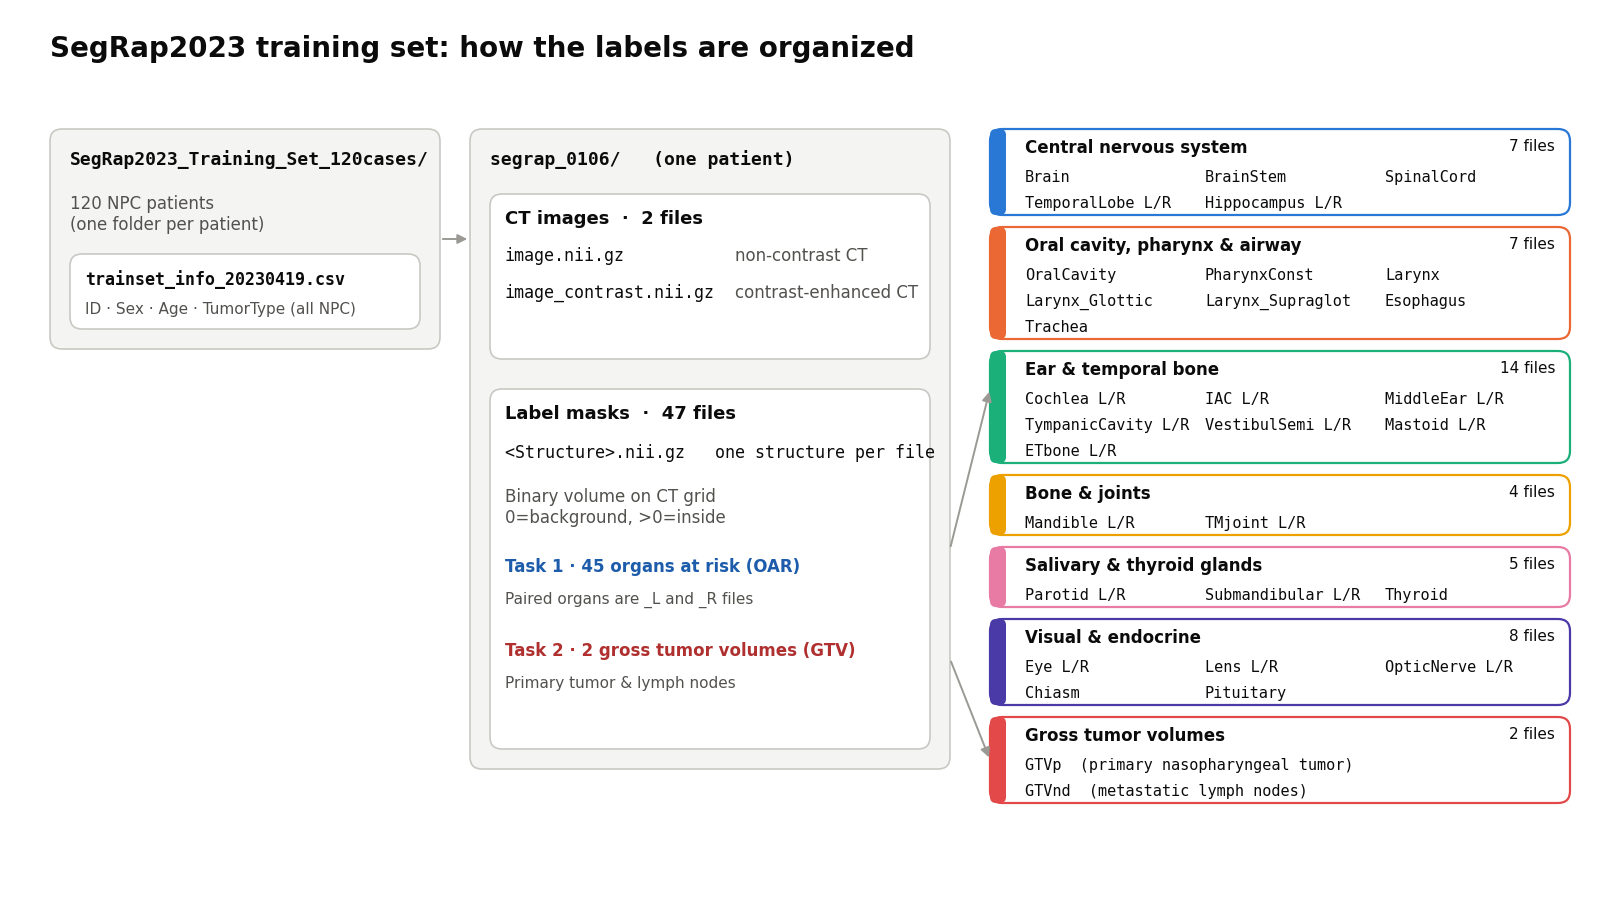

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

INK, INK2, MUTED, SURF = '#0b0b0b', '#52514e', '#8a8985', '#ffffff'
GROUPS = [
    ('Central nervous system', '#2a78d6', ['Brain', 'BrainStem', 'SpinalCord', 'TemporalLobe L/R', 'Hippocampus L/R']),
    ('Oral cavity, pharynx & airway', '#eb6834', ['OralCavity', 'PharynxConst', 'Larynx', 'Larynx_Glottic', 'Larynx_Supraglot', 'Esophagus', 'Trachea']),
    ('Ear & temporal bone', '#1baf7a', ['Cochlea L/R', 'IAC L/R', 'MiddleEar L/R', 'TympanicCavity L/R', 'VestibulSemi L/R', 'Mastoid L/R', 'ETbone L/R']),
    ('Bone & joints', '#eda100', ['Mandible L/R', 'TMjoint L/R']),
    ('Salivary & thyroid glands', '#e87ba4', ['Parotid L/R', 'Submandibular L/R', 'Thyroid']),
    ('Visual & endocrine', '#4a3aa7', ['Eye L/R', 'Lens L/R', 'OpticNerve L/R', 'Chiasm', 'Pituitary']),
]
GTV = ('Gross tumor volumes', '#e34948', ['GTVp  (primary nasopharyngeal tumor)', 'GTVnd  (metastatic lymph nodes)'])
nfiles = lambda ms: sum(2 if m.endswith('L/R') else 1 for m in ms)

fig = plt.figure(figsize=(16, 9), facecolor=SURF)
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 160); ax.set_ylim(0, 90); ax.set_axis_off()
def box(x, y, w, h, fc=SURF, ec='#c9c8c3', lw=1.2, r=1.2, z=1):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle=f'round,pad=0,rounding_size={r}', fc=fc, ec=ec, lw=lw, zorder=z))
def text(x, y, s, size=10, color=INK, weight='normal', ha='left', va='top', family='sans-serif'):
    ax.text(x, y, s, fontsize=size, color=color, weight=weight, ha=ha, va=va, family=family, zorder=3)
def arrow(x0, y0, x1, y1, rad=0.0):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle='-|>', mutation_scale=14, lw=1.4, color='#9a9994', connectionstyle=f'arc3,rad={rad}', zorder=2))

text(4, 87.5, 'SegRap2023 training set: how the labels are organized', 20, weight='bold')

# left box widened
box(4, 56, 39, 22, fc='#f4f4f2')
text(6, 76, 'SegRap2023_Training_Set_120cases/', 13, weight='bold', family='monospace')
text(6, 71.5, '120 NPC patients\n(one folder per patient)', 12, INK2)
box(6, 58, 35, 7.5)
text(7.5, 64, 'trainset_info_20230419.csv', 12, weight='bold', family='monospace')
text(7.5, 60.8, 'ID · Sex · Age · TumorType (all NPC)', 11, INK2)

# center box widened
box(46, 14, 48, 64, fc='#f4f4f2')
text(48, 76, 'segrap_0106/   (one patient)', 13, weight='bold', family='monospace')

box(48, 55, 44, 16.5)
text(49.5, 70, 'CT images  ·  2 files', 13, weight='bold')
text(49.5, 66.3, 'image.nii.gz', 12, family='monospace')
text(72.5, 66.3, 'non-contrast CT', 12, INK2)
text(49.5, 62.6, 'image_contrast.nii.gz', 12, family='monospace')
text(72.5, 62.6, 'contrast-enhanced CT', 12, INK2)

box(48, 16, 44, 36)
text(49.5, 50.5, 'Label masks  ·  47 files', 13, weight='bold')
text(49.5, 46.6, '<Structure>.nii.gz   one structure per file', 12, family='monospace')
text(49.5, 42.2, 'Binary volume on CT grid\n0=background, >0=inside', 12, INK2)
text(49.5, 35.2, 'Task 1 · 45 organs at risk (OAR)', 12, '#1c5cab', weight='bold')
text(49.5, 31.8, 'Paired organs are _L and _R files', 11, INK2)
text(49.5, 26.8, 'Task 2 · 2 gross tumor volumes (GTV)', 12, '#b03030', weight='bold')
text(49.5, 23.4, 'Primary tumor & lymph nodes', 11, INK2)

arrow(43, 67, 46, 67)

x3, w3, y = 98, 58, 78
col_step = 18
for label, color, members in GROUPS + [GTV]:
    cols = 1 if label == GTV[0] else 3
    rows = (len(members) + cols - 1) // cols
    h = 3.4 + rows * 2.6
    box(x3, y - h, w3, h, ec=color, lw=1.6)
    box(x3, y - h, 1.6, h, fc=color, ec=color, lw=0, r=0.6, z=2)
    text(x3 + 3.5, y - 0.9, label, 12, weight='bold')
    text(x3 + w3 - 1.5, y - 0.9, f'{nfiles(members)} files', 11, INK, ha='right')
    for i, m in enumerate(members):
        text(x3 + 3.5 + (i % cols) * col_step, y - 4.0 - (i // cols) * 2.6, m, 11, INK, family='monospace')
    if label == GTV[0]: y_gtv_mid = y - h / 2
    y -= h + 1.2

arrow(94, 36, 98, 52)
arrow(94, 25, 98, y_gtv_mid)

path='/mnt/data/segrap_fixed_test2.png'
fig.savefig(path, dpi=150, facecolor=SURF)
plt.close(fig)
path


## 5 · Organ volumes for every mask of every case → `outputs/organ_volumes.csv`

Already computed once on a laptop and saved to Drive, so this cell just loads it. Delete `RECOMPUTE = False` → `True` to redo it in Colab (reads ~5,600 masks, roughly an hour on a 2-CPU runtime; resumes if interrupted).

In [ ]:
# 5 · ORGAN VOLUME TABLE (load, or recompute)
import os, csv, time, numpy as np, nibabel as nib, pandas as pd
from multiprocessing import Pool

RECOMPUTE = False
VOL_CSV = OUT / 'organ_volumes.csv'

def volume(task):
    case, path = task
    try:
        img = nib.load(path); sx, sy, sz = (float(v) for v in img.header.get_zooms()[:3])
        n = int(np.count_nonzero(np.asarray(img.dataobj)))
        return case, os.path.basename(path)[:-7], n, sx, sy, sz, n * sx * sy * sz / 1000.0, ''
    except Exception as e:
        return case, os.path.basename(path)[:-7], -1, 0, 0, 0, float('nan'), repr(e)

if RECOMPUTE or not VOL_CSV.exists():
    done = set()
    if VOL_CSV.exists():
        prev = pd.read_csv(VOL_CSV); prev = prev[prev.error.isna() & (prev.voxels > 0)]
        prev.to_csv(VOL_CSV, index=False); done = set(zip(prev.case, prev.organ))
    tasks = [(c.name, str(p)) for c in sorted(DATA.glob('segrap_*')) for p in sorted(c.glob('*.nii.gz'))
             if not p.name.startswith('image') and '(' not in p.name and (c.name, p.name[:-7]) not in done]
    print(len(tasks), 'masks to compute,', len(done), 'already done')
    new = not VOL_CSV.exists(); t0 = time.time()
    with open(VOL_CSV, 'a', newline='') as f, Pool(os.cpu_count()) as pool:
        w = csv.writer(f)
        if new: w.writerow(['case', 'organ', 'voxels', 'sx', 'sy', 'sz', 'volume_cm3', 'error'])
        for i, row in enumerate(pool.imap_unordered(volume, tasks, chunksize=4), 1):
            w.writerow(row)
            if i % 100 == 0: f.flush(); el = time.time() - t0; print(f'{i}/{len(tasks)}  {el/60:.1f} min elapsed, ~{el/i*(len(tasks)-i)/60:.0f} min left')

vol = pd.read_csv(VOL_CSV)
bad = vol[vol.error.notna() | (vol.voxels <= 0)]
print(f'{vol.case.nunique()} cases, {len(vol)} masks, {len(bad)} failed reads' + (' → set RECOMPUTE=True and rerun to retry them' if len(bad) else ''))
vol.head()

120 cases, 5654 masks, 0 failed reads


,case,organ,voxels,sx,sy,sz,volume_cm3,error
0,segrap_0000,Brain,1706310,0.532227,0.532227,3.0,1450.014289,NaN
1,segrap_0000,BrainStem,41235,0.532227,0.532227,3.0,35.041311,NaN
2,segrap_0000,Chiasm,1596,0.532227,0.532227,3.0,1.356273,NaN
3,segrap_0000,Cochlea_L,218,0.532227,0.532227,3.0,0.185255,NaN
4,segrap_0000,Cochlea_R,213,0.532227,0.532227,3.0,0.181006,NaN


## 6 · Boxplots of organ volume across patients (needs cell 5's CSV)

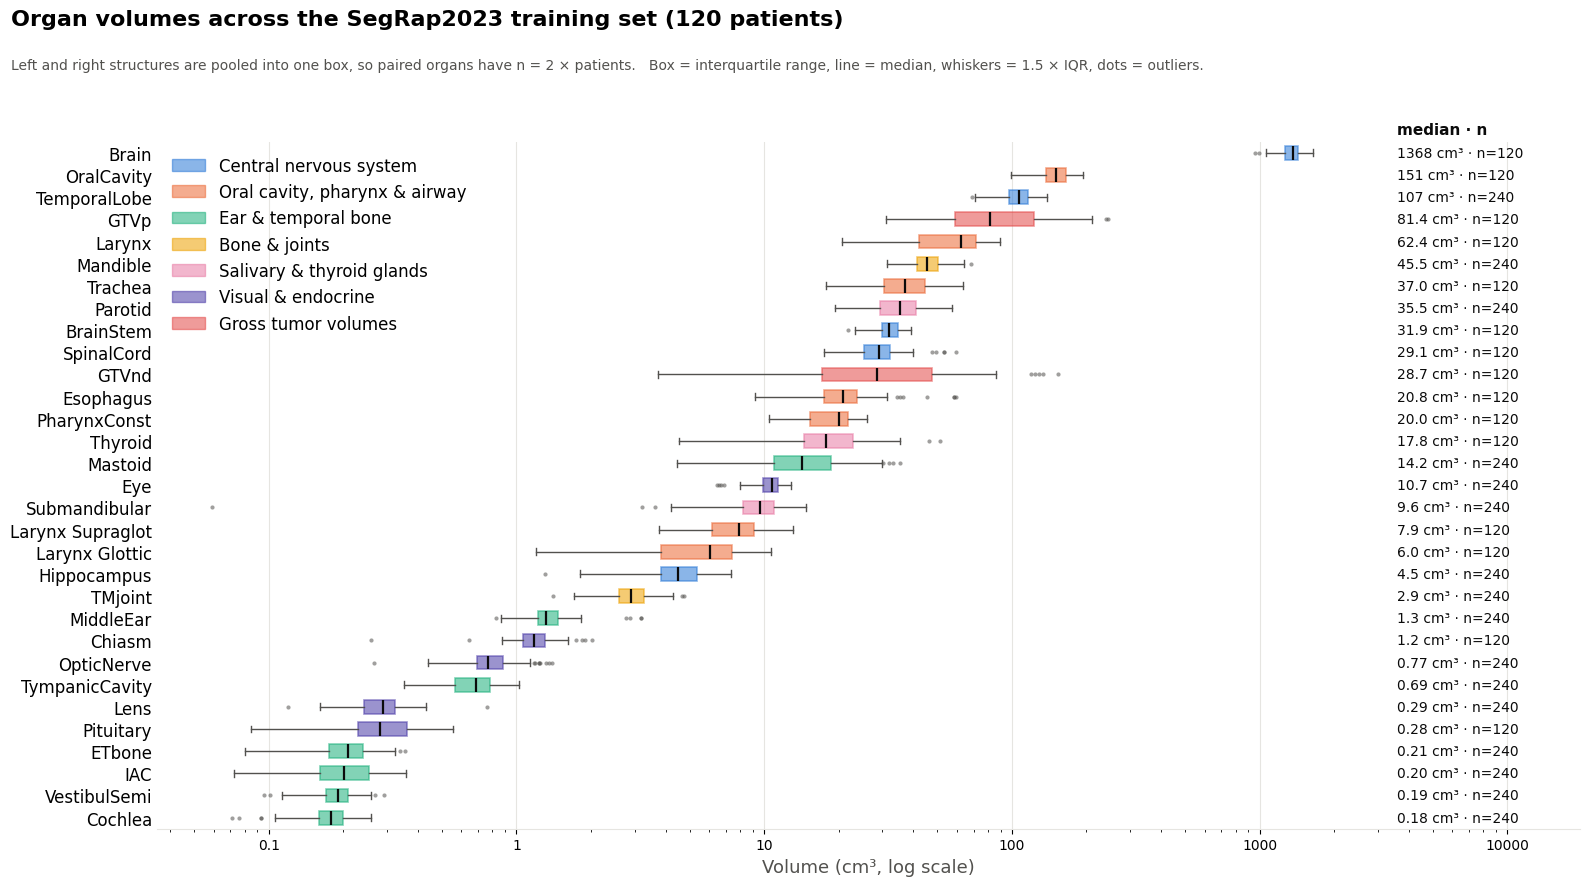

saved /content/drive/MyDrive/Biomedical Data Design/outputs/06_organ_volume_boxplots.png


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import LogLocator, FuncFormatter

INK, INK2, MUTED, GRID = '#0b0b0b', '#52514e', '#8a8985', '#e6e5e1'
GROUPS = {
    'Central nervous system': ('#2a78d6', ['Brain', 'BrainStem', 'SpinalCord', 'TemporalLobe', 'Hippocampus']),
    'Oral cavity, pharynx & airway': ('#eb6834', ['OralCavity', 'PharynxConst', 'Larynx', 'Larynx_Glottic', 'Larynx_Supraglot', 'Esophagus', 'Trachea']),
    'Ear & temporal bone': ('#1baf7a', ['Cochlea', 'IAC', 'MiddleEar', 'TympanicCavity', 'VestibulSemi', 'Mastoid', 'ETbone']),
    'Bone & joints': ('#eda100', ['Mandible', 'TMjoint']),
    'Salivary & thyroid glands': ('#e87ba4', ['Parotid', 'Submandibular', 'Thyroid']),
    'Visual & endocrine': ('#4a3aa7', ['Eye', 'Lens', 'OpticNerve', 'Chiasm', 'Pituitary']),
    'Gross tumor volumes': ('#e34948', ['GTVp', 'GTVnd']),
}
color_of = {o: c for g, (c, os_) in GROUPS.items() for o in os_}

df = pd.read_csv(OUT / 'organ_volumes.csv')
df = df[df.error.isna() & (df.voxels > 0)]
df['organ_base'] = df.organ.str.replace(r'_[LR]$', '', regex=True)
df = df[df.organ_base.isin(color_of)]                      # drops stray duplicates like "Eye_L (1)"
ncases = df.case.nunique()

stats = df.groupby('organ_base').volume_cm3.agg(['median', 'count', 'min', 'max']).sort_values('median')
organs = list(stats.index)
data = [df.loc[df.organ_base == o, 'volume_cm3'].values for o in organs]

fig, ax = plt.subplots(figsize=(16, 9), facecolor='white')
import matplotlib; horiz = {'orientation': 'horizontal'} if tuple(map(int, matplotlib.__version__.split('.')[:2])) >= (3, 10) else {'vert': False}
bp = ax.boxplot(data, **horiz, widths=0.62, patch_artist=True, whis=1.5,
                medianprops=dict(color=INK, lw=1.6), whiskerprops=dict(color=INK2, lw=1.0), capprops=dict(color=INK2, lw=1.0),
                flierprops=dict(marker='o', markersize=3, markerfacecolor=INK2, markeredgecolor='none', alpha=0.55))
for patch, o in zip(bp['boxes'], organs):
    patch.set_facecolor(color_of[o]); patch.set_alpha(0.55); patch.set_edgecolor(color_of[o]); patch.set_linewidth(1.2)
ax.set_xscale('log'); ax.set_xlim(stats['min'].min() * 0.6, stats['max'].max() * 12)
ax.xaxis.set_major_locator(LogLocator(base=10, numticks=8)); ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
ax.set_xlabel('Volume (cm³, log scale)', fontsize=13, color=INK2)
ax.set_yticks(range(1, len(organs) + 1)); ax.set_yticklabels([o.replace('_', ' ') for o in organs], fontsize=12)
ax.tick_params(axis='y', length=0); ax.grid(axis='x', color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ('top', 'right', 'left'): ax.spines[s].set_visible(False)
ax.spines['bottom'].set_color(GRID)
xr = stats['max'].max() * 2.2
for i, o in enumerate(organs, 1):
    med, n = stats.loc[o, 'median'], int(stats.loc[o, 'count'])
    lab = f'{med:.2f}' if med < 1 else (f'{med:.1f}' if med < 100 else f'{med:.0f}')
    ax.text(xr, i, f'{lab} cm³ · n={n}', va='center', ha='left', fontsize=10, color=INK)
ax.text(xr, len(organs) + 1.05, 'median · n', va='center', ha='left', fontsize=11, color=INK, weight='bold')
ax.legend(handles=[Patch(facecolor=c, alpha=0.55, edgecolor=c, label=g) for g, (c, _) in GROUPS.items()], loc='upper left', frameon=False, fontsize=12, labelcolor='black')
fig.suptitle(f'Organ volumes across the SegRap2023 training set ({ncases} patients)', x=0.01, ha='left', fontsize=16, weight='bold')
fig.text(0.01, 0.925, 'Left and right structures are pooled into one box, so paired organs have n = 2 × patients.   Box = interquartile range, line = median, whiskers = 1.5 × IQR, dots = outliers.', fontsize=10, color=INK2, va='top')
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(OUT / '06_organ_volume_boxplots.png', dpi=200, facecolor='white'); plt.show()
print('saved', OUT / '06_organ_volume_boxplots.png')

## 7 · Patient metadata (sex, age, tumor type)

Quick look at `trainset_info_20230419.csv` for the dataset-description slide.

TumorType
NPC    120 

Sex
Male      81
Female    39 

count    120.0
mean      48.0
std       11.6
min       22.0
25%       41.0
50%       49.0
75%       56.0
max       74.0


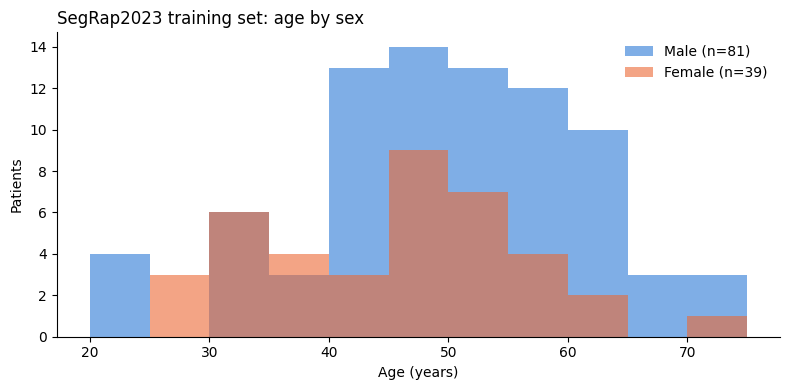

In [ ]:
# 7 · PATIENT METADATA
import pandas as pd, matplotlib.pyplot as plt
info = pd.read_csv(DATA / 'trainset_info_20230419.csv')
print(info.TumorType.value_counts().to_string(), '\n')
print(info.Sex.value_counts().to_string(), '\n')
print(info.Age.describe().round(1).to_string())
fig, ax = plt.subplots(figsize=(8, 4), facecolor='white')
for sex, c in (('Male', '#2a78d6'), ('Female', '#eb6834')):
    ax.hist(info.Age[info.Sex == sex], bins=range(20, 80, 5), alpha=0.6, color=c, label=f'{sex} (n={int((info.Sex == sex).sum())})')
ax.set_xlabel('Age (years)'); ax.set_ylabel('Patients'); ax.legend(frameon=False); ax.set_title('SegRap2023 training set: age by sex', loc='left')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
fig.tight_layout(); fig.savefig(OUT / '07_age_by_sex.png', dpi=200); plt.show()

## 2 · Model comparison

Generate a simple schematic showing the two experimental pipelines:
nnU-Net trained from scratch versus pretrained NV-Segment-CT fine-tuned on the same labeled SegRap2023 subsets.

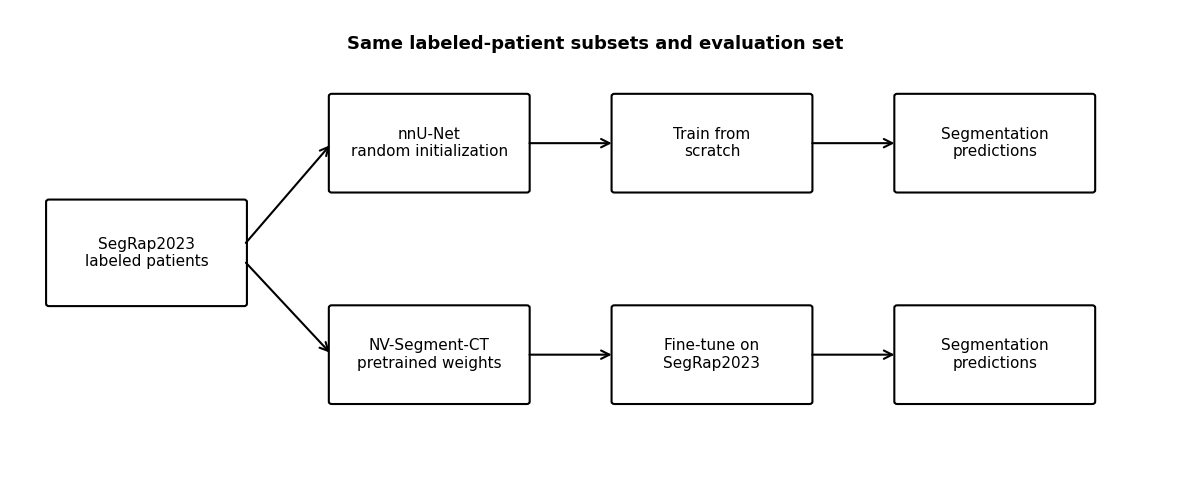

In [ ]:
# 2 · MODEL COMPARISON DIAGRAM

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

def box(x, y, w, h, text):
    patch = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        facecolor="white"
    )
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text,
            ha="center", va="center", fontsize=11)
    return patch

def arrow(x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5
        )
    )

# Shared input
box(0.4, 2.25, 2.0, 1.3,
    "SegRap2023\nlabeled patients")

# Top branch
box(3.3, 3.7, 2.0, 1.2,
    "nnU-Net\nrandom initialization")
box(6.2, 3.7, 2.0, 1.2,
    "Train from\nscratch")
box(9.1, 3.7, 2.0, 1.2,
    "Segmentation\npredictions")

# Bottom branch
box(3.3, 1.0, 2.0, 1.2,
    "NV-Segment-CT\npretrained weights")
box(6.2, 1.0, 2.0, 1.2,
    "Fine-tune on\nSegRap2023")
box(9.1, 1.0, 2.0, 1.2,
    "Segmentation\npredictions")

arrow(2.4, 3.0, 3.3, 4.3)
arrow(2.4, 2.8, 3.3, 1.6)

arrow(5.3, 4.3, 6.2, 4.3)
arrow(8.2, 4.3, 9.1, 4.3)

arrow(5.3, 1.6, 6.2, 1.6)
arrow(8.2, 1.6, 9.1, 1.6)

ax.text(
    6.0, 5.5,
    "Same labeled-patient subsets and evaluation set",
    ha="center", fontsize=13, fontweight="bold"
)

fig.tight_layout()
fig.savefig(OUT / "02_model_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 3 · SegRap2023 dataset overview

Show one representative CT volume and summarize the patient-level structure of the dataset.

Case: segrap_0060
Non-contrast volume shape: (1024, 1024, 121)
Voxel spacing: (np.float32(0.56152344), np.float32(0.56152344), np.float32(3.0))
Automatically selected axial slice: 24


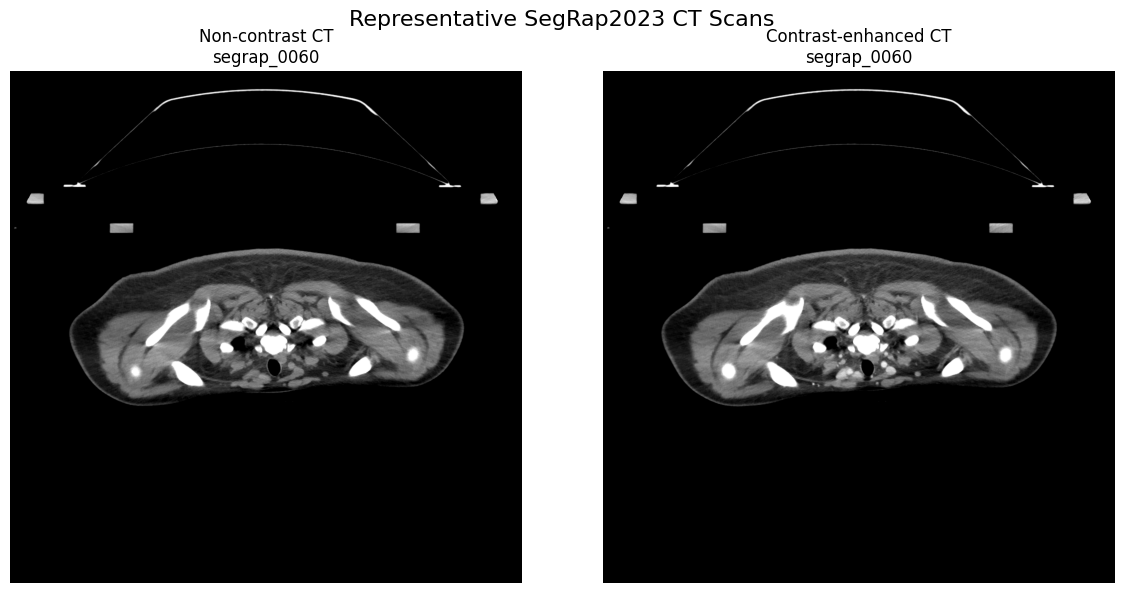

In [ ]:
# 3 · DATASET OVERVIEW — REPRESENTATIVE CT WITH AUTOMATIC SLICE SELECTION

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def nifti_files(case_dir):
    return sorted(Path(case_dir).rglob("*.nii.gz"))

def find_image_file(case_dir, contrast=False):
    """
    Locate the CT image file for a SegRap2023 case.
    """
    files = nifti_files(case_dir)

    if contrast:
        candidates = [
            f for f in files
            if "contrast" in f.name.lower()
            and "label" not in str(f).lower()
        ]
    else:
        candidates = [
            f for f in files
            if "image" in f.name.lower()
            and "contrast" not in f.name.lower()
            and "label" not in str(f).lower()
        ]

    if len(candidates) == 0:
        return None

    return candidates[0]


# Pick one representative patient
case_name = cases[len(cases) // 2]
case_dir = DATA / case_name

# Load non-contrast CT volume
nc_img_path = find_image_file(case_dir, contrast=False)
if nc_img_path is None:
    raise FileNotFoundError(
        f"Could not find the non-contrast CT image for {case_name}"
    )
nc_img = nib.load(nc_img_path)
nc_vol = nc_img.get_fdata()

# Load contrast-enhanced CT volume
ce_img_path = find_image_file(case_dir, contrast=True)
if ce_img_path is None:
    print(f"Warning: Could not find the contrast-enhanced CT image for {case_name}. Skipping ceCT display.")
    ce_vol = None
else:
    ce_img = nib.load(ce_img_path)
    ce_vol = ce_img.get_fdata()

print("Case:", case_name)
print("Non-contrast volume shape:", nc_vol.shape)
print("Voxel spacing:", nc_img.header.get_zooms()[:3])


# ------------------------------------------------
# Automatically choose a better axial slice
# ------------------------------------------------

slice_scores = []

for z in range(nc_vol.shape[2]):

    sl = nc_vol[:, :, z]

    # Approximate patient tissue:
    # remove air/background
    tissue_mask = sl > -500

    # Count tissue pixels
    score = np.sum(tissue_mask)

    slice_scores.append(score)


slice_scores = np.array(slice_scores)

# Avoid slices near the extreme top/bottom of the volume
lower = int(nc_vol.shape[2] * 0.20)
upper = int(nc_vol.shape[2] * 0.80)

valid_scores = slice_scores[lower:upper]

best_z = lower + np.argmax(valid_scores)

print("Automatically selected axial slice:", best_z)


# ------------------------------------------------
# Display selected CT slices
# ------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Non-contrast CT display
nc_sl = nc_vol[:, :, best_z]
nc_sl_windowed = np.clip(nc_sl, -150, 250)

axes[0].imshow(
    np.rot90(nc_sl_windowed),
    cmap="gray",
    vmin=-150,
    vmax=250
)

axes[0].set_title(
    f"Non-contrast CT\n{case_name}"
)
axes[0].axis("off")

# Contrast-enhanced CT display
if ce_vol is not None:
    ce_sl = ce_vol[:, :, best_z]
    ce_sl_windowed = np.clip(ce_sl, -150, 250)

    axes[1].imshow(
        np.rot90(ce_sl_windowed),
        cmap="gray",
        vmin=-150,
        vmax=250
    )

    axes[1].set_title(
        f"Contrast-enhanced CT\n{case_name}"
    )
    axes[1].axis("off")
else:
    axes[1].set_title(
        f"Contrast-enhanced CT\n(Not found for {case_name})"
    )
    axes[1].axis("off")

fig.suptitle("Representative SegRap2023 CT Scans", fontsize=16)
fig.tight_layout()

fig.savefig(
    OUT / "03_representative_CT_nc_ce.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3B · Quantify contrast enhancement across anatomical regions

This section quantifies contrast enhancement (difference between ceCT and ncCT intensities) within specific anatomical regions (organs) for a subset of patients. It calculates:

*   **Mean Enhancement (ΔHU_R)**: Average difference in Hounsfield Units (HU).
*   **90th Percentile of Absolute Difference**: The value below which 90% of the absolute intensity differences fall.
*   **Fraction of Voxels Exceeding Threshold**: The proportion of voxels where the absolute intensity difference is greater than a specified threshold (e.g., 20 HU or 30 HU).
*   **Standard Deviation of Enhancement**: Variability of the enhancement within the region.

In [ ]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path

# --- Configuration for this analysis ---
N_ENHANCEMENT_PATIENTS = 10  # Number of patients to sample for this analysis

# Organs to analyze for contrast enhancement (example selection)
SELECTED_ENHANCEMENT_ORGANS = [
    'Parotid_L', 'Submandibular_L', 'Thyroid', 'OralCavity', 'BrainStem'
]

# Thresholds for 'fraction of voxels exceeding threshold' metric
TAU_1 = 20 # HU
TAU_2 = 30 # HU

# --- Sample patients for this analysis ---
# Ensure 'cases' variable is available from setup cells
if 'cases' not in locals():
    print("Warning: 'cases' variable not found. Please run setup cells.")
    # Fallback (example if setup is not run, adjust as needed)
    # For this example, I will assume setup has been run and cases is available.
    # In a real scenario, I might generate the setup cells if needed.

# Select patients spread across the dataset
sample_indices_enhancement = np.linspace(
    0,
    len(cases) - 1,
    N_ENHANCEMENT_PATIENTS,
    dtype=int
)

enhancement_cases = [
    cases[i] for i in sample_indices_enhancement
]

print(f"Analyzing contrast enhancement for {len(enhancement_cases)} patients and {len(SELECTED_ENHANCEMENT_ORGANS)} organs.")
print(f"Sample patients: {enhancement_cases[:3]}...")


Analyzing contrast enhancement for 10 patients and 5 organs.
Sample patients: ['segrap_0000', 'segrap_0013', 'segrap_0026']...


In [ ]:
# --- Helper functions for contrast enhancement analysis ---

# The 'find_image_file' function is assumed to be defined in cell QaY0UA25O8ns
# For robustness, we will include a simplified version here if it's not present globally.
# In a typical Colab workflow, functions defined earlier in the notebook are available.
# However, to be safe, I'll include a minimal version here.

# Re-defining 'nifti_files' and 'find_image_file' to ensure availability in this context.
# In a production notebook, these might be in a shared utility cell.
def _nifti_files(case_dir):
    return sorted(Path(case_dir).rglob("*.nii.gz"))

def _find_image_file(case_dir, contrast=False):
    """
    Locate the CT image file for a SegRap2023 case.
    This is a local copy for this analysis to ensure availability.
    """
    files = _nifti_files(case_dir)
    if contrast:
        candidates = [f for f in files if "contrast" in f.name.lower() and "label" not in str(f).lower()]
    else:
        candidates = [f for f in files if "image" in f.name.lower() and "contrast" not in f.name.lower() and "label" not in str(f).lower()]
    if len(candidates) == 0: return None
    return candidates[0]

def find_mask_file(case_dir, organ_name):
    """
    Locate a specific organ mask file for a given case and organ name.
    """
    files = _nifti_files(case_dir)
    for f in files:
        # Ensure we match the exact organ name, excluding '.nii.gz'
        if f.name.replace('.nii.gz', '') == organ_name:
            return f
    return None

def calculate_enhancement_metrics(
    case_dir, organ_name, tau1=TAU_1, tau2=TAU_2
):
    """
    Calculates contrast enhancement metrics for a given organ in a patient's CT scans.
    """
    nc_path = _find_image_file(case_dir, contrast=False)
    ce_path = _find_image_file(case_dir, contrast=True)
    mask_path = find_mask_file(case_dir, organ_name)

    if nc_path is None or ce_path is None or mask_path is None:
        # print(f"Skipping {case_dir.name}/{organ_name}: Missing ncCT, ceCT, or mask file.")
        return None  # Cannot perform analysis without all necessary files

    try:
        # Explicitly load CT volumes as float32 for arithmetic operations
        nc_vol = nib.load(nc_path).get_fdata(dtype=np.float32)
        ce_vol = nib.load(ce_path).get_fdata(dtype=np.float32)
        mask_vol = nib.load(mask_path).get_fdata(dtype=np.uint8) # Mask as uint8 for memory
    except Exception as e:
        print(f"Error loading files for {case_dir.name}/{organ_name}: {e}")
        return None

    # Simple check for shape compatibility. More robust alignment might be needed for real data.
    if nc_vol.shape != ce_vol.shape or nc_vol.shape != mask_vol.shape:
        print(f"Shape mismatch for {case_dir.name}/{organ_name}. Skipping.")
        return None

    # Apply mask to extract relevant voxel values
    organ_mask = mask_vol > 0
    if not organ_mask.any():
        # print(f"Mask is empty for {case_dir.name}/{organ_name}. Skipping.")
        return None

    inc_values = nc_vol[organ_mask]
    ic_values = ce_vol[organ_mask]

    # Calculate difference
    diff_values = ic_values - inc_values
    abs_diff_values = np.abs(diff_values)

    # Ensure there are values to process after masking
    if len(diff_values) == 0:
        return None

    # 1. Mean Difference (ΔHU_R)
    mean_diff_hu = np.mean(diff_values)

    # 2. 90th percentile of absolute difference (Q_0.9(|Ic - Inc|))
    q90_abs_diff = np.percentile(abs_diff_values, 90)

    # 3. Fraction of voxels exceeding thresholds (P_R(|D| > τ))
    fraction_gt_tau1 = np.sum(abs_diff_values > tau1) / len(abs_diff_values)
    fraction_gt_tau2 = np.sum(abs_diff_values > tau2) / len(abs_diff_values)

    # 4. Standard Deviation of enhancement (SD_x∈R(D(x)))
    std_dev_enhancement = np.std(diff_values)

    return {
        'case': case_dir.name,
        'organ': organ_name,
        'mean_enhancement_HU': mean_diff_hu,
        'q90_abs_diff_HU': q90_abs_diff,
        f'frac_gt_{tau1}HU': fraction_gt_tau1,
        f'frac_gt_{tau2}HU': fraction_gt_tau2,
        'std_enhancement_HU': std_dev_enhancement
    }

print("Helper functions for contrast enhancement analysis defined.")

Helper functions for contrast enhancement analysis defined.


In [ ]:
# --- Perform contrast enhancement analysis ---

enhancement_results = []

for i, case_name in enumerate(enhancement_cases):
    case_dir = DATA / case_name
    print(f"Processing patient {i + 1}/{len(enhancement_cases)}: {case_name}")

    for organ_name in SELECTED_ENHANCEMENT_ORGANS:
        result = calculate_enhancement_metrics(case_dir, organ_name)
        if result is not None:
            enhancement_results.append(result)

enhancement_df = pd.DataFrame(enhancement_results)

print(f"\nAnalysis complete. Collected {len(enhancement_df)} enhancement measurements.")
display(enhancement_df.head())


Processing patient 1/10: segrap_0000
Error loading files for segrap_0000/Parotid_L: uint8 should be floating point type
Error loading files for segrap_0000/Submandibular_L: uint8 should be floating point type
Error loading files for segrap_0000/Thyroid: uint8 should be floating point type
Error loading files for segrap_0000/OralCavity: uint8 should be floating point type
Error loading files for segrap_0000/BrainStem: uint8 should be floating point type
Processing patient 2/10: segrap_0013
Error loading files for segrap_0013/Parotid_L: uint8 should be floating point type
Error loading files for segrap_0013/Submandibular_L: uint8 should be floating point type
Error loading files for segrap_0013/Thyroid: uint8 should be floating point type
Error loading files for segrap_0013/OralCavity: uint8 should be floating point type
Error loading files for segrap_0013/BrainStem: uint8 should be floating point type
Processing patient 3/10: segrap_0026
Error loading files for segrap_0026/Parotid_L: ui

""


In [ ]:
# --- Display aggregated contrast enhancement results ---

if not enhancement_df.empty:
    print("\nAggregated Contrast Enhancement Metrics:")
    # Group by organ and calculate mean/median for each metric
    aggregated_metrics = enhancement_df.groupby('organ').agg(
        mean_enhancement_HU=('mean_enhancement_HU', 'mean'),
        median_enhancement_HU=('mean_enhancement_HU', 'median'),
        mean_q90_abs_diff_HU=('q90_abs_diff_HU', 'mean'),
        mean_frac_gt_20HU=(f'frac_gt_{TAU_1}HU', 'mean'),
        mean_frac_gt_30HU=(f'frac_gt_{TAU_2}HU', 'mean'),
        mean_std_enhancement_HU=('std_enhancement_HU', 'mean'),
        num_measurements=('case', 'count')
    ).round(2)
    display(aggregated_metrics)

    # Optional: Visualize a specific metric, e.g., mean enhancement
    fig, ax = plt.subplots(figsize=(10, 6))
    aggregated_metrics['mean_enhancement_HU'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title('Mean Contrast Enhancement (ΔHU) per Organ')
    ax.set_xlabel('Organ')
    ax.set_ylabel('Mean ΔHU')
    ax.tick_params(axis='x', rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(OUT / "03b_mean_enhancement_per_organ.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved mean enhancement plot to {OUT / '03b_mean_enhancement_per_organ.png'}")
else:
    print("No enhancement data collected to display.")


No enhancement data collected to display.


## 4 · SegRap2023 image characteristics

Quantify variation in scan dimensions and spatial resolution across patients.

- Number of axial slices per patient
- Voxel spacing across patients

,case,nx,ny,nz,spacing_x,spacing_y,spacing_z
0,segrap_0000,1024,1024,127,0.532227,0.532227,3.0
1,segrap_0001,1024,1024,137,0.599609,0.599609,3.0
2,segrap_0002,1024,1024,121,0.569336,0.569336,3.0
3,segrap_0003,1024,1024,120,0.510742,0.510742,3.0
4,segrap_0004,1024,1024,129,0.557617,0.557617,3.0


             nx        ny      nz  spacing_x  spacing_y  spacing_z
count   120.000   120.000  120.00    120.000    120.000    120.000
mean   1011.200  1011.200  127.60      0.553      0.553      3.000
std      80.271    80.271   12.88      0.095      0.095      0.002
min     512.000   512.000   98.00      0.434      0.434      3.000
25%    1024.000  1024.000  121.00      0.515      0.515      3.000
50%    1024.000  1024.000  126.00      0.542      0.542      3.000
75%    1024.000  1024.000  132.00      0.570      0.570      3.000
max    1024.000  1024.000  197.00      1.131      1.131      3.023


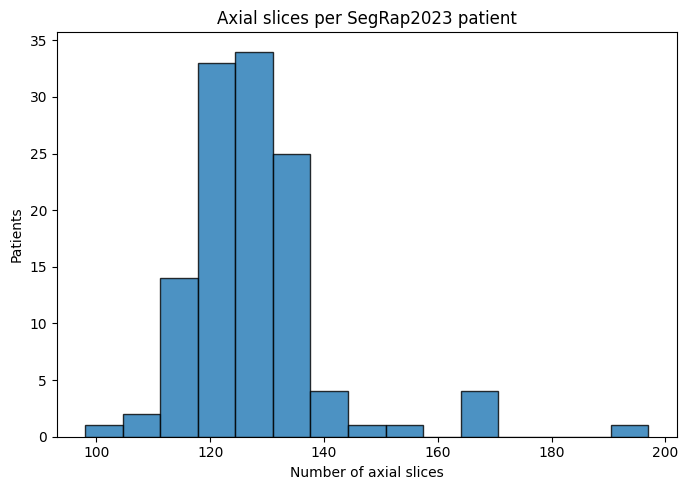

In [ ]:
# 4A · NUMBER OF AXIAL SLICES PER PATIENT

import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

scan_records = []

for case_name in cases:

    case_dir = DATA / case_name
    img_path = find_image_file(case_dir, contrast=False)

    if img_path is None:
        print("Skipping:", case_name, "— no ncCT found")
        continue

    img = nib.load(img_path)

    shape = img.shape
    spacing = img.header.get_zooms()[:3]

    scan_records.append({
        "case": case_name,
        "nx": shape[0],
        "ny": shape[1],
        "nz": shape[2],
        "spacing_x": spacing[0],
        "spacing_y": spacing[1],
        "spacing_z": spacing[2]
    })

scan_df = pd.DataFrame(scan_records)

display(scan_df.head())
print(scan_df.describe().round(3))


fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    scan_df["nz"],
    bins=15,
    edgecolor="black",
    alpha=0.8
)

ax.set_xlabel("Number of axial slices")
ax.set_ylabel("Patients")
ax.set_title("Axial slices per SegRap2023 patient")

fig.tight_layout()

fig.savefig(
    OUT / "04_axial_slice_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_2286/4239967712.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


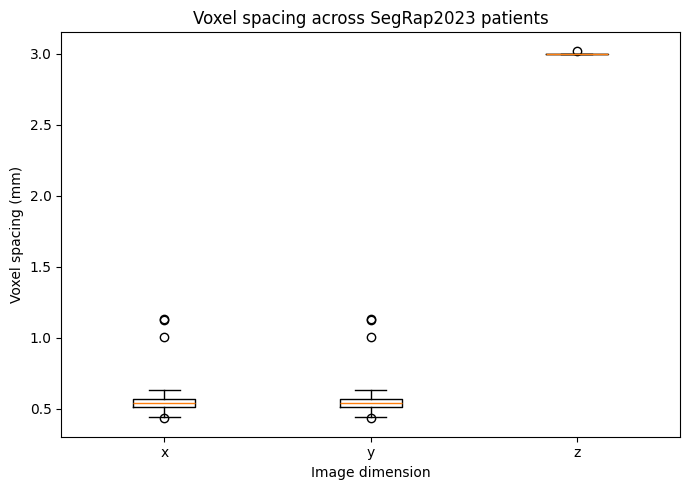

In [ ]:
# 4B · VOXEL SPACING ACROSS PATIENTS

spacing_long = scan_df[
    ["spacing_x", "spacing_y", "spacing_z"]
].copy()

spacing_long.columns = [
    "x",
    "y",
    "z"
]

fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [
        spacing_long["x"],
        spacing_long["y"],
        spacing_long["z"]
    ],
    labels=[
        "x",
        "y",
        "z"
    ],
    showfliers=True
)

ax.set_ylabel("Voxel spacing (mm)")
ax.set_xlabel("Image dimension")
ax.set_title("Voxel spacing across SegRap2023 patients")

fig.tight_layout()

fig.savefig(
    OUT / "04_voxel_spacing.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5 · CT intensity distributions and normalization

Compare CT intensity distributions using a representative subset of SegRap2023 patients.

1. Compare intensity distributions across representative patients
2. Compare non-contrast CT (ncCT) and contrast-enhanced CT (ceCT)

A representative subset is used to reduce runtime while preserving the overall distributional comparison.

In [ ]:
# 5 · SAMPLE PATIENTS FOR INTENSITY ANALYSIS

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

N_INTENSITY_PATIENTS = 25

sample_indices = np.linspace(
    0,
    len(cases) - 1,
    N_INTENSITY_PATIENTS,
    dtype=int
)

intensity_cases = [
    cases[i] for i in sample_indices
]

print(
    f"Using {len(intensity_cases)} representative patients "
    f"out of {len(cases)} total."
)

Using 25 representative patients out of 120 total.


### 5A · Intensity distributions across representative patients

Compare non-contrast CT intensity distributions across several individual patients.

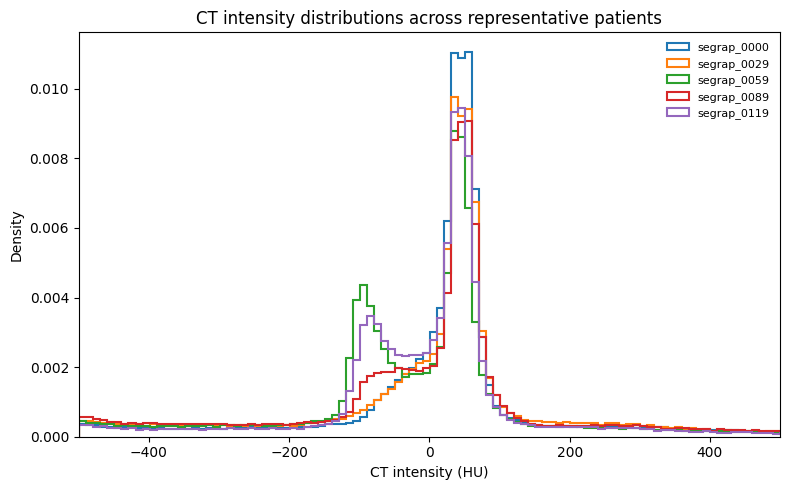

In [ ]:
# 5A · INTENSITY DISTRIBUTIONS ACROSS REPRESENTATIVE PATIENTS

# Use 5 patients spread throughout the sampled subset
display_indices = np.linspace(
    0,
    len(intensity_cases) - 1,
    5,
    dtype=int
)

representative_cases = [
    intensity_cases[i]
    for i in display_indices
]

fig, ax = plt.subplots(figsize=(8, 5))

rng = np.random.default_rng(42)

for case_name in representative_cases:

    img_path = find_image_file(
        DATA / case_name,
        contrast=False
    )

    if img_path is None:
        print("Skipping:", case_name)
        continue

    vol = nib.load(
        img_path
    ).get_fdata(
        dtype=np.float32
    )

    values = vol[
        (vol > -500) &
        (vol < 1000)
    ]

    # Sample voxels to keep memory and plotting fast
    if len(values) > 150000:
        values = rng.choice(
            values,
            size=150000,
            replace=False
        )

    ax.hist(
        values,
        bins=150,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=case_name
    )

    del vol
    del values

ax.set_xlim(-500, 500)

ax.set_xlabel("CT intensity (HU)")
ax.set_ylabel("Density")

ax.set_title(
    "CT intensity distributions across representative patients"
)

ax.legend(
    fontsize=8,
    frameon=False
)

fig.tight_layout()

fig.savefig(
    OUT / "05_patient_intensity_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5B · Non-contrast versus contrast-enhanced CT

Compare pooled ncCT and ceCT intensity distributions using 25 representative patients.

Processing 1/25: segrap_0000
Processing 2/25: segrap_0004
Processing 3/25: segrap_0009
Processing 4/25: segrap_0014
Processing 5/25: segrap_0019
Processing 6/25: segrap_0024
Processing 7/25: segrap_0029
Processing 8/25: segrap_0034
Processing 9/25: segrap_0039
Processing 10/25: segrap_0044
Processing 11/25: segrap_0049
Processing 12/25: segrap_0054
Processing 13/25: segrap_0059
Processing 14/25: segrap_0064
Processing 15/25: segrap_0069
Processing 16/25: segrap_0074
Processing 17/25: segrap_0079
Processing 18/25: segrap_0084
Processing 19/25: segrap_0089
Processing 20/25: segrap_0094
Processing 21/25: segrap_0099
Processing 22/25: segrap_0104
Processing 23/25: segrap_0109
Processing 24/25: segrap_0114
Processing 25/25: segrap_0119


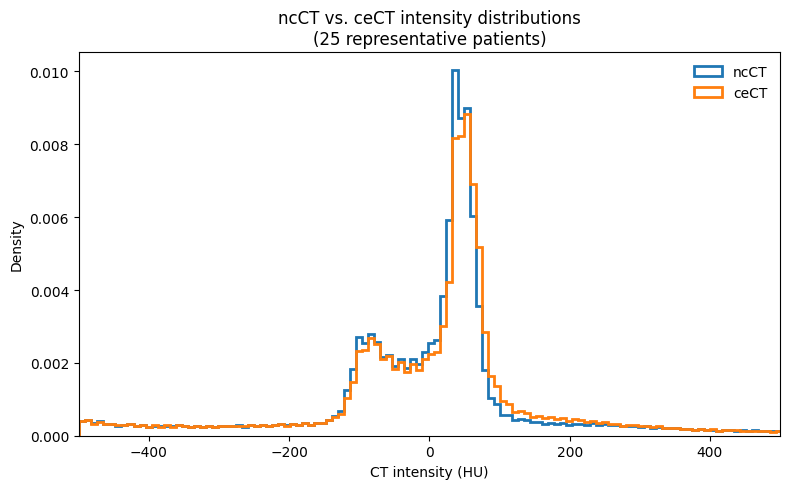

ncCT sampled voxels: 500000
ceCT sampled voxels: 500000


In [ ]:
# 5B · ncCT VS ceCT — SAMPLED PATIENTS

rng = np.random.default_rng(42)

nc_values_all = []
ce_values_all = []

for i, case_name in enumerate(intensity_cases):

    print(
        f"Processing {i + 1}/{len(intensity_cases)}: "
        f"{case_name}"
    )

    case_dir = DATA / case_name

    nc_path = find_image_file(
        case_dir,
        contrast=False
    )

    ce_path = find_image_file(
        case_dir,
        contrast=True
    )

    # -------------------------
    # Non-contrast CT
    # -------------------------

    if nc_path is not None:

        nc = nib.load(
            nc_path
        ).get_fdata(
            dtype=np.float32
        )

        nc = nc[
            (nc > -500) &
            (nc < 1000)
        ]

        # Store only a subset of voxels per patient
        if len(nc) > 20000:
            nc = rng.choice(
                nc,
                size=20000,
                replace=False
            )

        nc_values_all.append(nc)


    # -------------------------
    # Contrast-enhanced CT
    # -------------------------

    if ce_path is not None:

        ce = nib.load(
            ce_path
        ).get_fdata(
            dtype=np.float32
        )

        ce = ce[
            (ce > -500) &
            (ce < 1000)
        ]

        if len(ce) > 20000:
            ce = rng.choice(
                ce,
                size=20000,
                replace=False
            )

        ce_values_all.append(ce)


# Combine sampled voxels
nc_values_all = np.concatenate(
    nc_values_all
)

ce_values_all = np.concatenate(
    ce_values_all
)


# -------------------------
# Plot
# -------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    nc_values_all,
    bins=175,
    density=True,
    histtype="step",
    linewidth=2,
    label="ncCT"
)

ax.hist(
    ce_values_all,
    bins=175,
    density=True,
    histtype="step",
    linewidth=2,
    label="ceCT"
)

ax.set_xlim(-500, 500)

ax.set_xlabel("CT intensity (HU)")
ax.set_ylabel("Density")

ax.set_title(
    "ncCT vs. ceCT intensity distributions\n"
    "(25 representative patients)"
)

ax.legend(frameon=False)

fig.tight_layout()

fig.savefig(
    OUT / "05_ncCT_vs_ceCT_sampled.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "ncCT sampled voxels:",
    len(nc_values_all)
)

print(
    "ceCT sampled voxels:",
    len(ce_values_all)
)

## 8 · Annotation boundary characteristics

Estimate boundary complexity using a representative subset of SegRap2023 patients and anatomical structures.

For each sampled structure:

1. Identify the 3D mask boundary
2. Compute the structure centroid
3. Measure centroid-to-boundary distances
4. Normalize variability by the mean distance
5. Compare boundary complexity across structures

Sampling patients and masks keeps runtime manageable while preserving the exploratory comparison.

In [ ]:
# 8 · SAMPLE PATIENTS AND MASKS

!pip install -q scipy

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.ndimage import binary_erosion


# -----------------------------
# Sampling settings
# -----------------------------

N_BOUNDARY_PATIENTS = 8
N_MASKS_PER_PATIENT = 10

rng = np.random.default_rng(42)


# Select patients spread across the dataset
sample_indices = np.linspace(
    0,
    len(cases) - 1,
    N_BOUNDARY_PATIENTS,
    dtype=int
)

boundary_cases = [
    cases[i]
    for i in sample_indices
]

print(
    f"Using {len(boundary_cases)} patients "
    f"and up to {N_MASKS_PER_PATIENT} masks per patient."
)

Using 8 patients and up to 10 masks per patient.


### 8A · Helper functions

In [ ]:
# 8A · HELPER FUNCTIONS

def find_mask_files(case_dir):
    """
    Find segmentation-mask NIfTI files while excluding CT images.
    """

    files = sorted(
        Path(case_dir).rglob("*.nii.gz")
    )

    masks = []

    for f in files:

        name = f.name.lower()
        path_text = str(f).lower()

        # Exclude CT image volumes
        if name in [
            "image.nii.gz",
            "image_contrast.nii.gz"
        ]:
            continue

        if (
            "image" in name
            and "mask" not in name
            and "label" not in path_text
        ):
            continue

        masks.append(f)

    return masks


def structure_name(path):
    """
    Return a clean structure name from filename.
    """

    name = path.name

    if name.endswith(".nii.gz"):
        name = name[:-7]

    return name


def boundary_complexity(mask):
    """
    Coefficient of variation of centroid-to-boundary distances.
    """

    mask = mask.astype(bool)

    coords = np.argwhere(mask)

    if len(coords) < 20:
        return None

    centroid = coords.mean(axis=0)

    eroded = binary_erosion(mask)

    boundary = mask & (~eroded)

    boundary_coords = np.argwhere(
        boundary
    )

    if len(boundary_coords) < 10:
        return None

    distances = np.linalg.norm(
        boundary_coords - centroid,
        axis=1
    )

    mean_distance = distances.mean()

    if mean_distance == 0:
        return None

    return distances.std() / mean_distance

### 8B · Compute boundary complexity

Calculate boundary complexity for 20 representative patients.

In [ ]:
# 8B · COMPUTE BOUNDARY COMPLEXITY — FAST VERSION

boundary_records = []

for case_i, case_name in enumerate(boundary_cases):

    case_dir = DATA / case_name

    mask_files = find_mask_files(
        case_dir
    )

    # Randomly sample masks if there are more than needed
    if len(mask_files) > N_MASKS_PER_PATIENT:

        selected_idx = rng.choice(
            len(mask_files),
            size=N_MASKS_PER_PATIENT,
            replace=False
        )

        selected_masks = [
            mask_files[i]
            for i in selected_idx
        ]

    else:
        selected_masks = mask_files


    print(
        f"[{case_i + 1}/{len(boundary_cases)}] "
        f"{case_name} — processing "
        f"{len(selected_masks)} masks"
    )


    for mask_i, mask_path in enumerate(selected_masks):

        print(
            f"   mask {mask_i + 1}/{len(selected_masks)}: "
            f"{mask_path.name}"
        )

        try:

            img = nib.load(
                mask_path
            )

            mask_data = img.get_fdata(
                dtype=np.float32
            )

            mask = mask_data > 0

            complexity = boundary_complexity(
                mask
            )

            if complexity is None:
                continue

            boundary_records.append({
                "case": case_name,
                "structure": structure_name(
                    mask_path
                ),
                "boundary_complexity": complexity,
                "n_voxels": int(
                    mask.sum()
                )
            })

            del mask_data
            del mask

        except Exception as e:

            print(
                "Skipped:",
                mask_path.name,
                "|",
                e
            )


boundary_df = pd.DataFrame(
    boundary_records
)

print("\nFinished.")

print(
    "Total measurements:",
    len(boundary_df)
)

print(
    "Unique structures:",
    boundary_df[
        "structure"
    ].nunique()
)

display(
    boundary_df.head()
)

[1/8] segrap_0000 — processing 10 masks
   mask 1/10: TympanicCavity_L.nii.gz
   mask 2/10: Parotid_L.nii.gz
   mask 3/10: Cochlea_L.nii.gz
   mask 4/10: MiddleEar_R.nii.gz
   mask 5/10: Larynx_Glottic.nii.gz
   mask 6/10: Larynx_Supraglot.nii.gz
   mask 7/10: Parotid_R.nii.gz
   mask 8/10: Cochlea_R.nii.gz
   mask 9/10: Eye_R.nii.gz
   mask 10/10: Submandibular_R.nii.gz
[2/8] segrap_0017 — processing 10 masks
   mask 1/10: Pituitary.nii.gz
   mask 2/10: Larynx_Supraglot.nii.gz
   mask 3/10: IAC_L.nii.gz
   mask 4/10: OpticNerve_R.nii.gz
   mask 5/10: TMjoint_L.nii.gz
   mask 6/10: Esophagus.nii.gz
   mask 7/10: Larynx_Glottic.nii.gz
   mask 8/10: Lens_L.nii.gz
   mask 9/10: MiddleEar_L.nii.gz
   mask 10/10: TMjoint_R.nii.gz
[3/8] segrap_0034 — processing 10 masks
   mask 1/10: OralCavity.nii.gz
   mask 2/10: Parotid_R.nii.gz
   mask 3/10: GTVnd.nii.gz
   mask 4/10: Lens_R.nii.gz
   mask 5/10: IAC_R.nii.gz
   mask 6/10: ETbone_R.nii.gz
   mask 7/10: Mastoid_R.nii.gz
   mask 8/10: Thyro

,case,structure,boundary_complexity,n_voxels
0,segrap_0000,TympanicCavity_L,0.391873,600
1,segrap_0000,Parotid_L,0.360028,30914
2,segrap_0000,Cochlea_L,0.377352,218
3,segrap_0000,MiddleEar_R,0.453530,1370
4,segrap_0000,Larynx_Glottic,0.328517,6586


### 8C · Select representative structures

Keep structures present in multiple sampled patients and select a manageable range from low to high boundary complexity.

In [ ]:
# 8C · SELECT STRUCTURES

structure_summary = (
    boundary_df
    .groupby("structure")
    .agg(
        median_complexity=(
            "boundary_complexity",
            "median"
        ),
        n_patients=(
            "case",
            "nunique"
        )
    )
    .sort_values(
        "median_complexity"
    )
)


# Since we sampled masks, requiring 4 patients is too strict.
# Keep structures that appear in at least 2 sampled patients.
structure_summary = structure_summary[
    structure_summary[
        "n_patients"
    ] >= 2
]


display(
    structure_summary
)


MAX_STRUCTURES = 10

if len(structure_summary) > MAX_STRUCTURES:

    selected_idx = np.linspace(
        0,
        len(structure_summary) - 1,
        MAX_STRUCTURES,
        dtype=int
    )

    selected_structures = list(
        structure_summary.iloc[
            selected_idx
        ].index
    )

else:

    selected_structures = list(
        structure_summary.index
    )


print(
    "Selected structures:",
    selected_structures
)

,median_complexity,n_patients
structure,,
GTVnd,0.244994,3
BrainStem,0.289248,2
Eye_R,0.305847,3
Eye_L,0.311059,2
Larynx_Glottic,0.330122,2
OralCavity,0.335027,2
Submandibular_R,0.355935,2
Mastoid_R,0.367821,2
Lens_L,0.368200,3


Selected structures: ['GTVnd', 'Eye_R', 'OralCavity', 'Lens_L', 'VestibulSemi_R', 'TMjoint_L', 'Hippocampus_L', 'IAC_L', 'ETbone_L', 'OpticNerve_R']


### 8D · Boundary complexity across structures

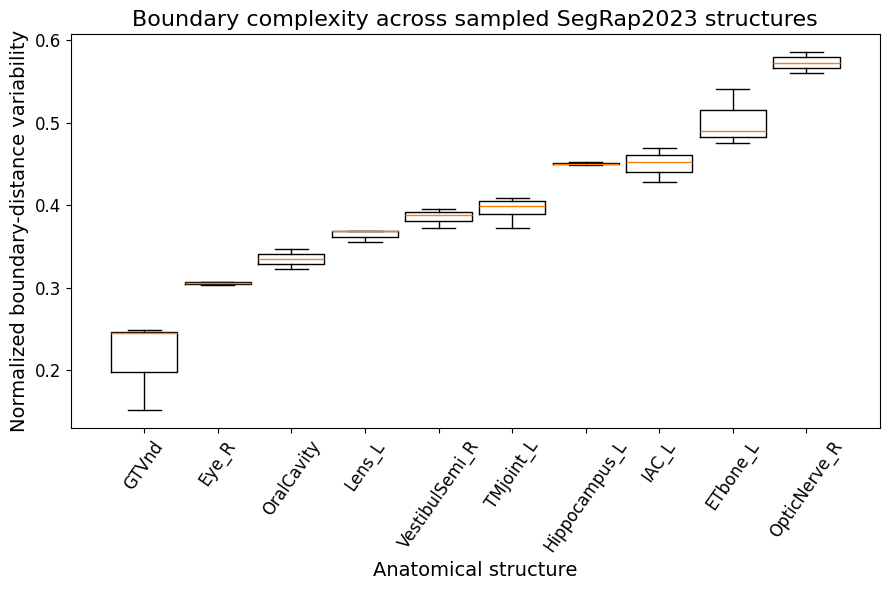

In [ ]:
spacing = 0.5
positions = np.arange(len(selected_structures)) * spacing

fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.45,
    showfliers=False
)

ax.set_xticks(positions)
ax.set_xticklabels(
    selected_structures,
    rotation=55,
    fontsize=12
)

ax.set_xlabel(
    "Anatomical structure",
    fontsize=14
)

ax.set_ylabel(
    "Normalized boundary-distance variability",
    fontsize=14
)

ax.set_title(
    "Boundary complexity across sampled SegRap2023 structures",
    fontsize=16
)

ax.tick_params(
    axis="y",
    labelsize=12
)

fig.tight_layout()

fig.savefig(
    OUT / "08_boundary_complexity_fast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 8E · Identify low- and high-complexity structures

In [ ]:
# 8E · LOW VS HIGH COMPLEXITY

ranked = structure_summary.sort_values(
    "median_complexity"
)

low_structure = ranked.index[0]
high_structure = ranked.index[-1]

print(
    "Lower-complexity structure:",
    low_structure
)

print(
    "Median complexity:",
    round(
        ranked.loc[
            low_structure,
            "median_complexity"
        ],
        3
    )
)

print()

print(
    "Higher-complexity structure:",
    high_structure
)

print(
    "Median complexity:",
    round(
        ranked.loc[
            high_structure,
            "median_complexity"
        ],
        3
    )
)

Lower-complexity structure: GTVnd
Median complexity: 0.245

Higher-complexity structure: OpticNerve_R
Median complexity: 0.573


### 8F · Representative low- and high-complexity contours

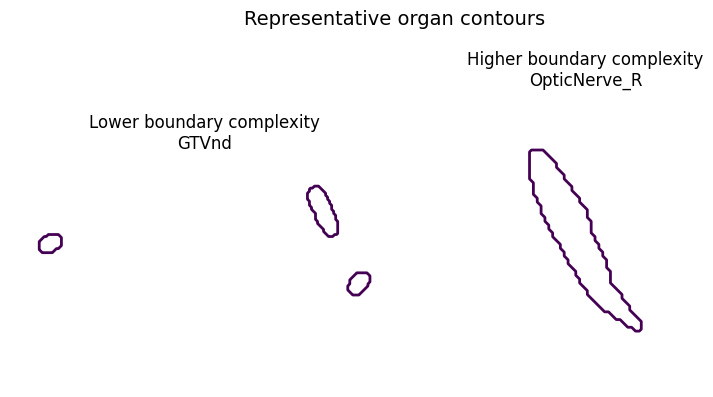

In [ ]:
# 8F · REPRESENTATIVE LOW- AND HIGH-COMPLEXITY CONTOURS
# Cropped around each structure for easier visualization

def find_structure_file(case_name, structure):

    for f in find_mask_files(
        DATA / case_name
    ):
        if structure_name(f) == structure:
            return f

    return None


def representative_structure_mask(structure):

    subset = boundary_df[
        boundary_df["structure"] == structure
    ].copy()

    median_value = subset[
        "boundary_complexity"
    ].median()

    subset["distance_from_median"] = (
        subset["boundary_complexity"]
        - median_value
    ).abs()

    row = subset.sort_values(
        "distance_from_median"
    ).iloc[0]

    mask_path = find_structure_file(
        row["case"],
        structure
    )

    mask = (
        nib.load(mask_path)
        .get_fdata(dtype=np.float32)
        > 0
    )

    return row["case"], mask


def best_slice(mask):
    """
    Choose the axial slice containing the largest mask area.
    """
    slice_areas = mask.sum(axis=(0, 1))
    return int(np.argmax(slice_areas))


def crop_to_mask(mask_slice, padding=15):
    """
    Crop a 2D mask around its nonzero pixels.
    """

    coords = np.argwhere(mask_slice)

    if len(coords) == 0:
        return mask_slice

    rmin, cmin = coords.min(axis=0)
    rmax, cmax = coords.max(axis=0)

    rmin = max(0, rmin - padding)
    rmax = min(mask_slice.shape[0], rmax + padding + 1)

    cmin = max(0, cmin - padding)
    cmax = min(mask_slice.shape[1], cmax + padding + 1)

    return mask_slice[
        rmin:rmax,
        cmin:cmax
    ]


# Load representative masks
low_case, low_mask = representative_structure_mask(
    low_structure
)

high_case, high_mask = representative_structure_mask(
    high_structure
)

# Select best axial slices
low_z = best_slice(low_mask)
high_z = best_slice(high_mask)

# Extract and rotate slices
low_slice = np.rot90(
    low_mask[:, :, low_z]
)

high_slice = np.rot90(
    high_mask[:, :, high_z]
)

# Crop tightly around each structure
low_crop = crop_to_mask(
    low_slice,
    padding=15
)

high_crop = crop_to_mask(
    high_slice,
    padding=15
)


# -----------------------------
# Plot
# -----------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].contour(
    low_crop,
    levels=[0.5],
    linewidths=2
)

axes[0].set_title(
    f"Lower boundary complexity\n"
    f"{low_structure}"
)

axes[0].set_aspect("equal")
axes[0].axis("off")


axes[1].contour(
    high_crop,
    levels=[0.5],
    linewidths=2
)

axes[1].set_title(
    f"Higher boundary complexity\n"
    f"{high_structure}"
)

axes[1].set_aspect("equal")
axes[1].axis("off")


fig.suptitle(
    "Representative organ contours",
    fontsize=14
)

fig.tight_layout()

fig.savefig(
    OUT / "08_low_vs_high_boundary_complexity_cropped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

del low_mask
del high_mask